In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors

import os


import seaborn as sns



## Load Data

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/'

In [ ]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster.tsv')

union_cell_info = pd.read_csv(Union_cell_file, sep='\t', index_col=0)

In [26]:
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI
atac_bc,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0


In [5]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']


_total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
_total_frag_per_bc.columns = ['total_fragments']
_total_frag_per_bc.head()


,total_fragments
atac_bc,
AAACAAGCAAACATGT,4
AAACAAGCAAACCAGC,1
AAACAAGCAAACCTAG,207
AAACAAGCAAACTAAC,1
AAACAAGCAAAGAAGC,987


In [13]:
all_valid_entropy_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_df.tsv')
all_valid_entropy = pd.read_csv(all_valid_entropy_file, sep=',', index_col=0)
all_valid_entropy['atac_bc'] = all_valid_entropy.index.map(lambda x: x.split('-1')[0])
all_valid_entropy.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,GAACAATGTCGGTTAT


In [ ]:
# DNA debris flag is only placed on non-empty barcodes. (i.e. empty barcodes are not DNA-debris by definition.)
DNAdebris_file = os.path.join(entropy_dir, 'entropy_filtered_bc_w_DNAdebrisflag_df.tsv')
DNAdebris_df = pd.read_csv(DNAdebris_file, sep=',', index_col=0)
DNAdebris_df['atac_bc'] = DNAdebris_df.index.map(lambda x: x.split('-1')[0])
DNAdebris_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
TCCTCCATCAGGTTCC-1,0.985064,0.500669,4760,0.105701,0.899693,0.428163,YES,TCCTCCATCAGGTTCC


In [29]:
total_frag_per_bc = _total_frag_per_bc.copy()

total_frag_per_bc['Entropy'] = total_frag_per_bc.index.map(all_valid_entropy.set_index('atac_bc')['Entropy'])
total_frag_per_bc['DNA_debris'] = total_frag_per_bc.index.map(DNAdebris_df.set_index('atac_bc')['DNA_debris'])
total_frag_per_bc['DNA_debris'].fillna('NO', inplace=True)
col_list = ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']
for col in col_list:
    total_frag_per_bc[col] = total_frag_per_bc.index.map(union_cell_info[col])
    if col == '_2set_identified_by_atac_SC' or col == '_2set_identified_by_atac_ST':
        total_frag_per_bc[col].fillna('none', inplace=True)

total_frag_per_bc.head(3)

/tmp/ipykernel_1343872/1440779117.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  total_frag_per_bc['DNA_debris'].fillna('NO', inplace=True)
/tmp/ipykernel_1343872/1440779117.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,total_fragments,Entropy,DNA_debris,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS
atac_bc,,,,,,,,,
AAACAAGCAAACATGT,4,NaN,NO,none,none,NaN,NaN,NaN,NaN
AAACAAGCAAACCAGC,1,NaN,NO,none,none,NaN,NaN,NaN,NaN
AAACAAGCAAACCTAG,207,0.011025,NO,none,none,NaN,NaN,NaN,NaN


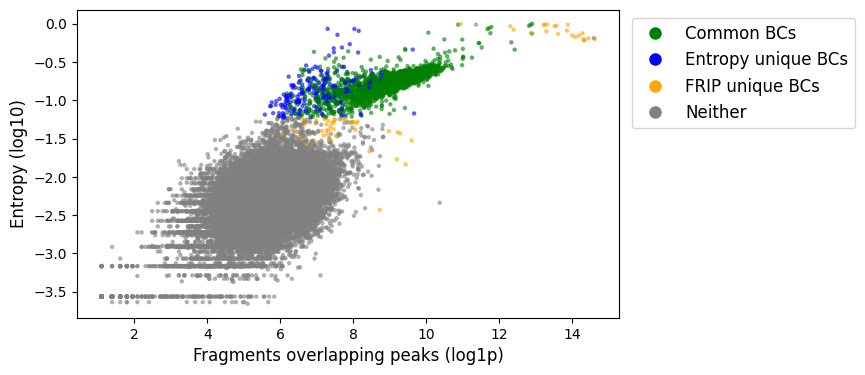

In [31]:
fig, ax = plt.subplots( figsize=(7, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac_SC'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping peaks (log1p)', fontsize=12)
ax.set_xlabel('Fragments overlapping peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)


ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common BCs',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy unique BCs',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='FRIP unique BCs',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Neither',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1.45, 1), loc='upper right', ncol=1, fontsize=12)

### How many barcoeds have invalid entropy values

In [33]:
total_frag_per_bc['invalid_entropy_value'] = total_frag_per_bc['Entropy'].isna() 
total_frag_per_bc['invalid_entropy_value'].value_counts()

invalid_entropy_value
True     255722
False     33287
Name: count, dtype: int64

In [34]:
total_frag_per_bc.groupby(['invalid_entropy_value', '_2set_identified_by_atac_SC']).size().unstack()

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
invalid_entropy_value,,,,
False,1865.0,81.0,236.0,31105.0
True,NaN,13.0,NaN,255709.0


In [41]:
total_frag_per_bc['atac_pass_entropy'] == True

atac_bc
AAACAAGCAAACATGT    False
AAACAAGCAAACCAGC    False
AAACAAGCAAACCTAG    False
AAACAAGCAAACTAAC    False
AAACAAGCAAAGAAGC    False
                    ...  
TTTGTGAGTTTGCTGG    False
TTTGTGAGTTTGGCTG    False
TTTGTGAGTTTGGTGT    False
TTTGTGAGTTTGGTTA    False
TTTGTGAGTTTGTTGA    False
Name: atac_pass_entropy, Length: 289009, dtype: bool

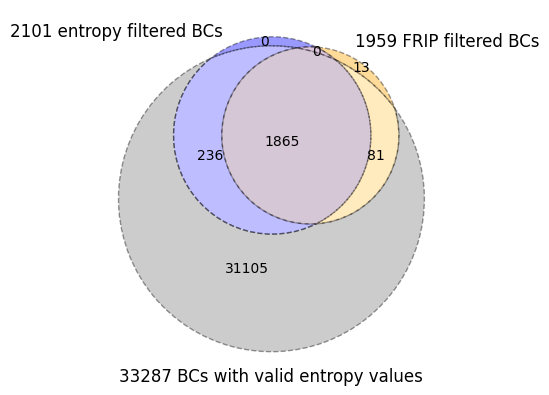

In [43]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based

venn_sets = {
    'Entropy unique BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy'] == True].index),
    'FRIP unique BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR'] == True].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy'] == True].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR'] == True].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy filtered BCs',f'{len(venn_sets[1])} FRIP filtered BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()



----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [np.float64(70.09293350553217), np.float64(53.7556943958199), np.float64(57.92354036811493), np.float64(25.241626412258334)]
median 	 [np.float64(72.42582897033158), np.float64(69.77886977886978), np.float64(65.44656099369669), np.float64(1.694915254237288)]


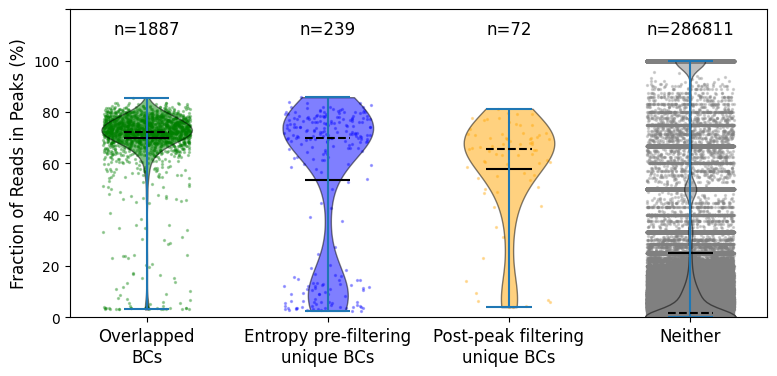

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy pre-filtering\nunique BCs', 'Post-peak filtering\nunique BCs', 'Neither'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

/tmp/ipykernel_188105/2519565810.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax0.get_xticks()  ], fontsize=12)
/tmp/ipykernel_188105/2519565810.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax1.get_xticks()  ], fontsize=12)


Text(3000, -1.5, '2126 BCs pass entropy pre-filtering')

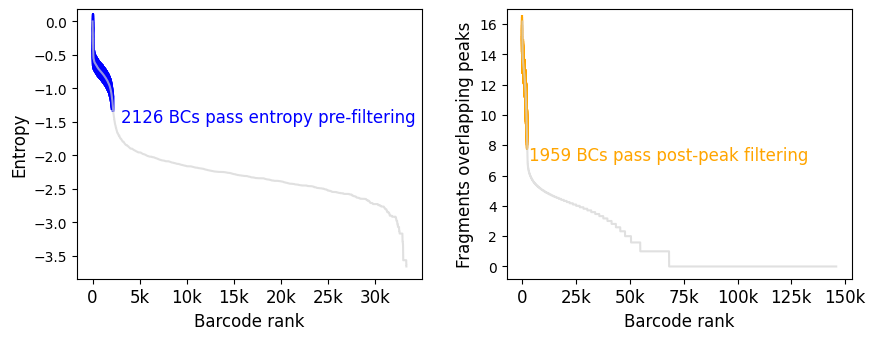

In [ ]:


fig = plt.figure(figsize=(10, 3.5))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[:,11:])

ax1 = fig.add_subplot(gs[:,:9])


# ax0
sorted_frag_overlap_peaks = np.log2(total_frag_per_bc['frag_overlap_CRpeaks']).sort_values(ascending=False).to_frame()  # with barcodes as index
rank_list = np.arange( sorted_frag_overlap_peaks.shape[0] )
sorted_frag_overlap_peaks['rank_list'] = rank_list

ax0.plot( sorted_frag_overlap_peaks['rank_list'], sorted_frag_overlap_peaks['frag_overlap_CRpeaks'], '-', markersize=7, color='lightgray', alpha=0.7)
ax0.set_xlabel('Barcode rank', fontsize=12)
# ax0.set_ylabel('Fragments overlapping peaks (log)', fontsize=12)
ax0.set_ylabel('Fragments overlapping peaks', fontsize=12)
ax0.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax0.get_xticks()  ], fontsize=12)


barcodes = total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index
ax0.scatter(sorted_frag_overlap_peaks.loc[barcodes, 'rank_list'], 
            sorted_frag_overlap_peaks.loc[barcodes, 'frag_overlap_CRpeaks'], color='orange', label='Cell', s=130, alpha=1, marker="|")

ax0.text(3000, 7, f'{len(barcodes)} BCs pass post-peak filtering', fontsize=12, color='orange')
# ax0.legend(title='CR \npost-peak\ncell-calling', bbox_to_anchor=(1, 1), loc='upper left')

# ax1
sorted_log10entropy_series = np.log10(total_frag_per_bc['Entropy'].dropna().sort_values(ascending=False)).to_frame()  # with barcodes as index
rank_list = np.arange( len(sorted_log10entropy_series) )
sorted_log10entropy_series['rank_list'] = rank_list


ax1.plot( rank_list, sorted_log10entropy_series['Entropy'], '-', markersize=7, color='lightgray', alpha=0.7)
ax1.set_xlabel('Barcode rank', fontsize=12)
#ax1.set_ylabel('Entropy (log10)', fontsize=12)
ax1.set_ylabel('Entropy', fontsize=12)
# ax1.set_xlim((-1000, 30000))
ax1.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax1.get_xticks()  ], fontsize=12)

barcodes = total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index
ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
            sorted_log10entropy_series.loc[barcodes, 'Entropy'], color='blue', label='Cell', s=130, alpha=1, marker="|")
    
# ax1.legend(title='Entropy \npre-filtering', bbox_to_anchor=(1, 1), loc='upper left')
ax1.text(3000, -1.5, f'{len(barcodes)} BCs pass entropy pre-filtering', fontsize=12, color='blue')


----- 	 both 	 entropy_only 	 cr_only (invalid entropy) 	 cr_only (valid entropy) 	 none
mean 	 [np.float64(70.093), np.float64(53.756), np.float64(25.242), np.float64(72.678), np.float64(54.672)]
median 	 [np.float64(72.426), np.float64(69.779), np.float64(1.695), np.float64(70.986), np.float64(63.244)]


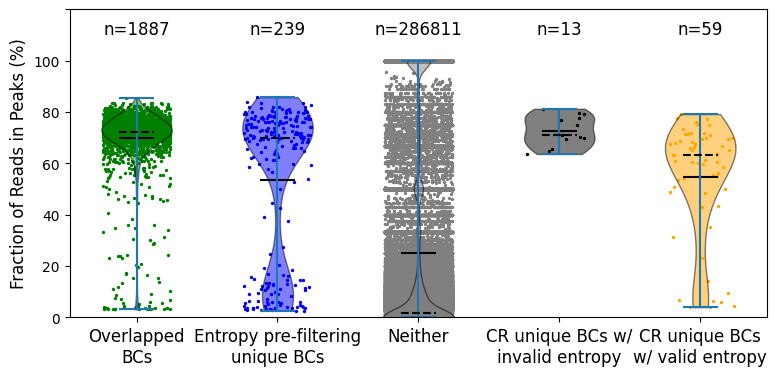

In [124]:
fig, ax = plt.subplots(figsize=(9, 4))



colors_map = ['green', 'blue', 'gray', 'black', 'orange']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only',  'none'] ]
frip_values.append( 
                   total_frag_per_bc.loc[(total_frag_per_bc['identified_by_atac'] == 'cr_only') & (total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )
frip_values.append(
                   total_frag_per_bc.loc[(total_frag_per_bc['identified_by_atac'] == 'cr_only') & (~total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )

total_counts = [a.shape[0] for a in frip_values]
mean_frip_values = [np.round(np.mean(a), 3) for a in frip_values]
median_frip_values = [np.round(np.median(a), 3) for a in frip_values]


x_positions = range(len(frip_values))
width = 0.5

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy pre-filtering\nunique BCs', 'Neither', 
                    'CR unique BCs w/\ninvalid entropy', 'CR unique BCs\nw/ valid entropy'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only (invalid entropy) \t cr_only (valid entropy) \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# Filter fragments by each category BCs

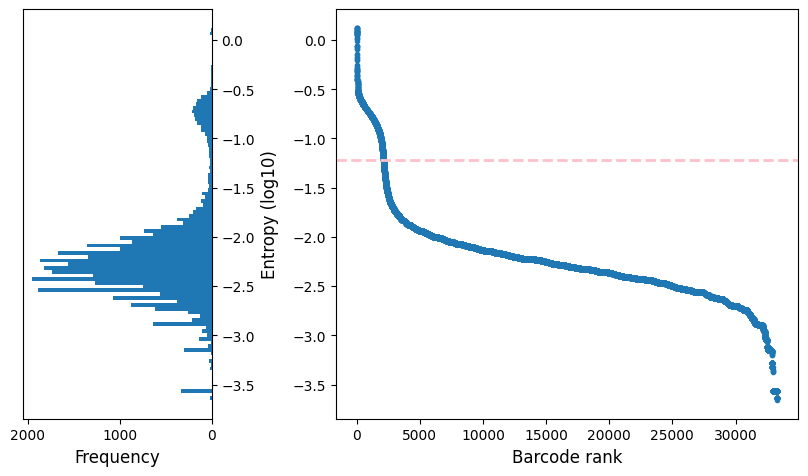

In [86]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:5])
_ = ax0.hist(np.log10(entropy_df['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,8:])

sorted_log10entropy_list = np.log10(entropy_df['Entropy'].dropna().sort_values(ascending=False).values)
rank_list = np.arange( len(sorted_log10entropy_list) )
entropy_cutoff = entropy_df.loc[entropy_df['atac_pass_entropy'], 'Entropy'].min()
entropy_cutoff_log = np.log10(entropy_cutoff)


ax1.plot( rank_list, sorted_log10entropy_list, 'o', markersize=3)
ax1.set_xlabel('Barcode rank', fontsize=12)
# ax1.set_ylabel('log(Entropy)', fontsize=12)
ax1.axhline(entropy_cutoff_log, color='pink', linestyle='--', label='entropy threshold', lw=2)


FRIP 	 entropy_only 	 cr_only 

Median 	 69.78 	 62.44 

Mean 	 53.76 	 54.52 



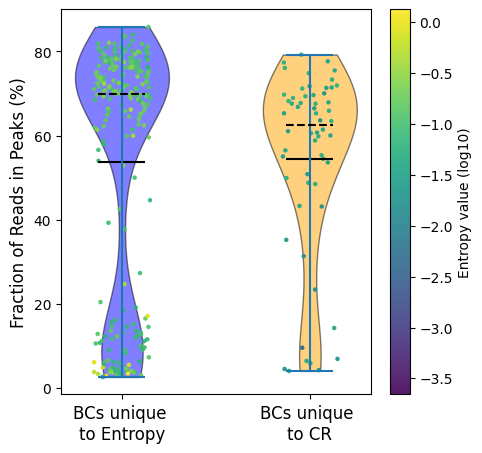

In [102]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
gps_anno = ['BCs unique \nto Entropy', 'BCs unique \nto CR']
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
FRIP_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'CRpeak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))



vp1 = ax.violinplot( FRIP_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=5, norm=norm) # s controls point size
    return color_bar



for i, group_data in enumerate(FRIP_data):
    cb = add_jittered_points(ax, group_data, x_positions[i], 0,   color=entropy_values[i],color_range=color_range, jitter_width=0.15)

colorbar = fig.colorbar(cb, ax=ax, label='Entropy value (log10)')


for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.5)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps_anno, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_peak = [FRIP_data[i].median() for i in range(len(gps))]
mean_frip_peak = [FRIP_data[i].mean() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_peak[0], median_frip_peak[1]))
print("Mean \t {:.2f} \t {:.2f} \n".format(mean_frip_peak[0], mean_frip_peak[1]))

FRIP 	 entropy_only 	 cr_only 

Median 	 69.78 	 62.44 



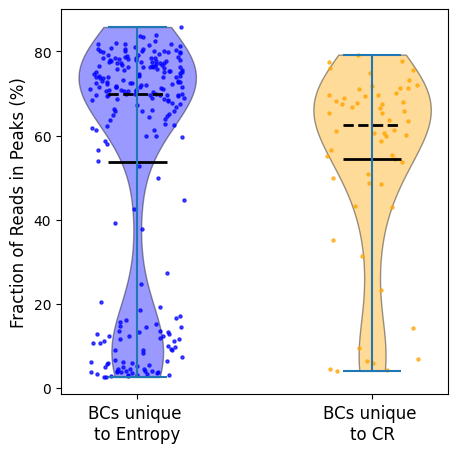

In [104]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
gps_anno = ['BCs unique \nto Entropy', 'BCs unique \nto CR']
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
FRIP_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'CRpeak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))


vp1 = ax.violinplot( FRIP_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.7, s=5) # s controls point size



for i, group_data in enumerate(FRIP_data):
    add_jittered_points(ax, group_data, x_positions[i], jitter_width=0.2, color='orange' if gps[i]=='cr_only' else 'blue')



for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.4)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmedians'].set_linewidth(2)
vp1['cmeans'].set_linewidth(2)
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps_anno, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_standard_peak = [FRIP_data[i].median() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_standard_peak[0], median_frip_standard_peak[1]))

Text(0, 0.5, 'Number of Fragments in Peaks')

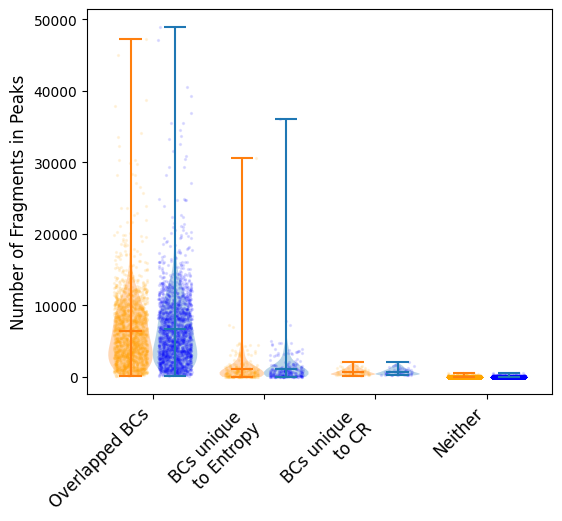

In [105]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'Neither':'gray'}
gps = ['both', 'entropy_only', 'cr_only', 'none']
gps_anno = ['Overlapped BCs', 'BCs unique \nto Entropy', 'BCs unique \nto CR', 'Neither']
x_positions = range(len(gps))
widths=0.4
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(6, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_standard_peak'] for c in gps]
entropy_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_entropy_peak'] for c in gps]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=[x - 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.1, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i] - 0.2, color=colors_map['cr_only'])
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + 0.2 for x in x_positions][i], color=colors_map['entropy_only'])

ax.set_xticks(x_positions)
ax.set_xticklabels(gps_anno, rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Number of Fragments in Peaks', fontsize=12)


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


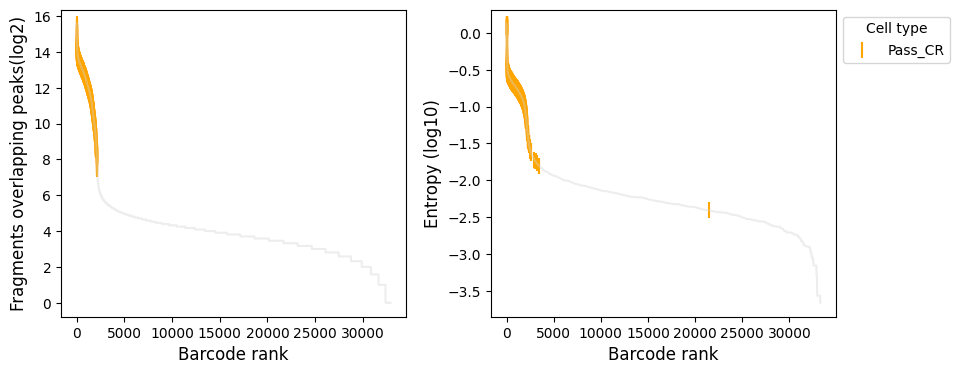

In [106]:


fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:9])

sorted_frag_overlap_peaks = np.log2(entropy_df['Nfrag_overlap_entropy_peak']).sort_values(ascending=False).to_frame()  # with barcodes as index
rank_list = np.arange( sorted_frag_overlap_peaks.shape[0] )
sorted_frag_overlap_peaks['rank_list'] = rank_list

ax0.plot( sorted_frag_overlap_peaks['rank_list'], sorted_frag_overlap_peaks['Nfrag_overlap_entropy_peak'], '-', markersize=1, color='lightgray', alpha=0.4)
ax0.set_xlabel('Barcode rank', fontsize=12)
ax0.set_ylabel('Fragments overlapping peaks(log2)', fontsize=12)

barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax0.scatter(sorted_frag_overlap_peaks.loc[barcodes, 'rank_list'], 
            sorted_frag_overlap_peaks.loc[barcodes, 'Nfrag_overlap_entropy_peak'], color='orange', label='Pass_CR', s=130, alpha=1, marker="|")



ax1 = fig.add_subplot(gs[0:20,11:])

sorted_log10entropy_series = np.log10(entropy_df['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)


barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
            sorted_log10entropy_series.loc[barcodes, 'Entropy'], color='orange', label='Pass_CR', s=130, alpha=1, marker="|")
    
ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')